# TEMPO — Trajectory-Level Initialization

**TEMPO** discovers $M$ latent regimes among training trajectories via Expectation-Maximization,
training a dedicated basis for each regime.

Each unit of clustering is a **full trajectory** $\mathbf{s}^n \in \mathbb{R}^{N_t N_x}$, not an individual snapshot.

Initialization (3 steps):
1. **Global POD** — SVD on all trajectories $\{\mathbf{s}^n\}_{n=1}^N$ → coefficients $\alpha^n \in \mathbb{R}^P$
2. **GMM** — fit Gaussian mixture on $\{\alpha^n\}$ → soft assignments $\gamma \in \mathbb{R}^{N \times M}$
3. **Regime bases** — train $M$ weighted bases: $\min_{\Phi_m} \sum_n \gamma_{nm} \|\mathbf{s}^n - \hat{\mathbf{s}}_m^n\|^2$

In [15]:
import sys, pathlib
import numpy as np
import torch
import matplotlib.pyplot as plt

from matplotlib.patches import Ellipse
from sklearn.manifold import TSNE
from umap import UMAP

sys.path.insert(0, str(pathlib.Path("..").resolve()))
from models.tempo import TEMPOTrainer, TEMPOConfig, pod_factory, fourier_pod_factory
from models.pod import PODConfig
from models.fourier_neural_pod import FourierNeuralPODConfig
from utils.datasets import load

if torch.backends.mps.is_available():   DEVICE = 'mps'
elif torch.cuda.is_available():         DEVICE = 'cuda'
else:                                   DEVICE = 'cpu'


def draw_cov_ellipse(ax, mean2d, cov2d, color, n_std=2.0, **kwargs):
    vals, vecs = np.linalg.eigh(cov2d)
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    w, h  = 2 * n_std * np.sqrt(np.abs(vals))
    ellipse = Ellipse(mean2d, w, h, angle=angle,
                      edgecolor=color, facecolor="none", lw=2, **kwargs)
    ax.add_patch(ellipse)

### Data

Parameters:

In [16]:
nu_values = [0.001, 0.01, 0.1, 1.0]
N_samples  = 5000

In [17]:
tensors, kappas = [], []

Loading:

In [18]:
for nu in nu_values:
    data = load(f"Burgers_Nu{nu}")
    u = data["tensor"][:N_samples, :, :, 0]   # (N_samples, Nt, Nx)
    t_np = data["t-coordinate"]                # (Nt,)
    x_np = data["x-coordinate"]               # (Nx,)

    N, Nt, Nx = u.shape
    u_traj = u.reshape(N, -1)                  # (N, Nt*Nx) — one row per trajectory
    k_flat = np.full(N, nu)                    # (N,)

    tensors.append(u_traj)
    kappas.append(k_flat)


In [19]:
s_np     = np.concatenate(tensors, axis=0)    # (N_total, Nt*Nx)
k_np_all = np.concatenate(kappas, axis=0)     # (N_total,)

# (x, t) coordinate pairs for all spatiotemporal points
x_grid = torch.tensor(x_np, dtype=torch.float32)
t_grid = torch.tensor(t_np, dtype=torch.float32)
tt, xx = torch.meshgrid(t_grid, x_grid, indexing='ij')              # (Nt, Nx)
x_flat = torch.stack([xx.flatten(), tt.flatten()], dim=1)           # (Nt*Nx, 2)

s     = torch.tensor(s_np,           dtype=torch.float32, device=DEVICE)   # (N_total, Nt*Nx)
x     = x_flat.to(DEVICE)
kappa = torch.tensor(k_np_all[:, None], dtype=torch.float32, device=DEVICE)

print(f"s={s.shape}, x={x.shape}, kappa={kappa.shape}")
# s=(24000, 25856), x=(25856, 2), kappa=(24000, 1)


s=torch.Size([20000, 25856]), x=torch.Size([25856, 2]), kappa=torch.Size([20000, 1])


# **TEMPO:**

### **POD**

In [20]:
cfg = TEMPOConfig(
    M=3,
    basis_config=PODConfig(max_modes=1),
    basis_factory=pod_factory,
    P_global = 5
)

regime_colors = np.array([
    [0.27, 0.51, 0.71, 1.0],
    [0.84, 0.37, 0.30, 1.0],
    [0.30, 0.64, 0.42, 1.0],
    [0.75, 0.55, 0.24, 1.0],
])[:cfg.M]

In [21]:
trainer = TEMPOTrainer(cfg)
trainer._initialize(s, x, t=None, kappa = kappa)

POD | N=20000, Ny=25856 | max_modes=5, tol=1.0
  P=5 modes (100.00% variance threshold, needed 9985)
  mode  1: sigma=9.6006e+01  cumvar=91.11%  res_mse=3.4801e-02
  mode  2: sigma=9.8753e+00  cumvar=92.07%  res_mse=3.1029e-02
  mode  3: sigma=9.7025e+00  cumvar=93.00%  res_mse=2.7388e-02
  mode  4: sigma=6.9995e+00  cumvar=93.48%  res_mse=2.5494e-02
  mode  5: sigma=6.9288e+00  cumvar=93.96%  res_mse=2.3637e-02
  done: final res_mse=2.3637e-02
POD | N=20000, Ny=25856 | max_modes=1, tol=0.9999


KeyboardInterrupt: 

In [ ]:
print(f"alpha:  {trainer.alpha.shape}")    #(N, P_global)
print(f"gamma:  {trainer.gamma.shape}")    # (N, M)
print(f"pi:     {trainer.pi.shape}")       # (M,)
print(f"mu:     {trainer.mu.shape}")       # (M, P_glob)
print(f"Sigma:  {trainer.Sigma.shape}")    # (M, P_glob, P_glob)
print(f"bases:  {len(trainer.trainers)}")  #  M

alpha:  torch.Size([8000, 5])
gamma:  torch.Size([8000, 3])
pi:     torch.Size([3])
mu:     torch.Size([3, 5])
Sigma:  torch.Size([3, 5, 5])
bases:  3


#### Latent structure of Burgers trajectories

- **UMAP:**

/Users/rknza/research/m1p/project/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


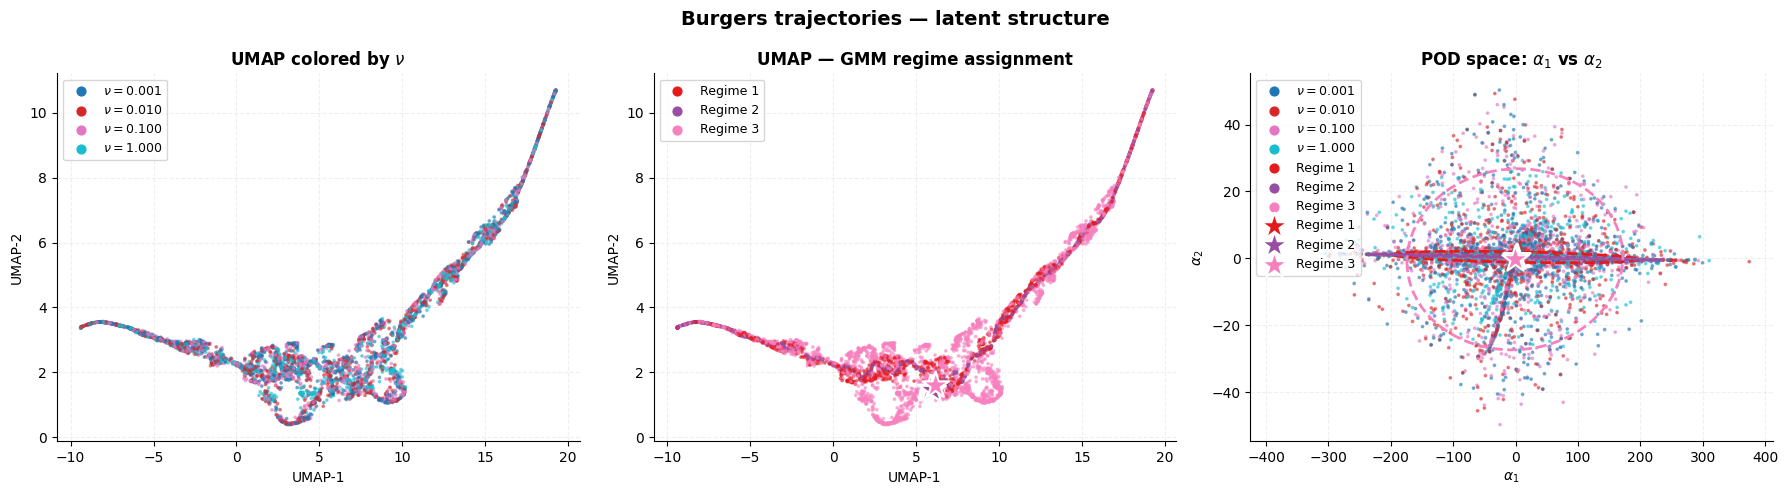

In [ ]:
N_viz = 5632
idx = np.random.choice(len(s), N_viz, replace=False)

kappa_viz   = kappa[idx, 0].cpu().numpy()
alpha_viz   = trainer.alpha[idx].cpu().numpy()
hard_labels = trainer.gamma[idx].argmax(dim=1).cpu().numpy()

reducer      = UMAP(n_neighbors=30, min_dist=0.0, random_state=39)
embedding    = reducer.fit_transform(alpha_viz)
mu_np        = trainer.mu.cpu().numpy()
mu_umap      = reducer.transform(mu_np)

nu_unique     = np.unique(kappa_viz)
colors        = plt.cm.tab10(np.linspace(0, 0.9, len(nu_unique)))
nu_to_col     = {nu: c for nu, c in zip(nu_unique, colors)}
point_colors  = np.array([nu_to_col[nu] for nu in kappa_viz])
regime_colors = plt.cm.Set1(np.linspace(0, 0.8, cfg.M))
star_kw       = dict(s=400, marker="*", zorder=10, edgecolors="white", linewidths=1.5)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# UMAP by nu
axes[0].scatter(embedding[:, 0], embedding[:, 1], c=point_colors, s=3, alpha=0.5)
axes[0].set_title(r"UMAP colored by $\nu$", fontweight="bold")
handles = [plt.scatter([], [], color=c, s=40, label=rf"$\nu={nu:.3f}$")
           for nu, c in zip(nu_unique, colors)]
axes[0].legend(handles=handles, fontsize=9)

# UMAP by regime
axes[1].scatter(embedding[:, 0], embedding[:, 1], c=regime_colors[hard_labels], s=3, alpha=0.5)
axes[1].scatter(mu_umap[:, 0], mu_umap[:, 1], c=regime_colors, **star_kw)
axes[1].set_title("UMAP — GMM regime assignment", fontweight="bold")
handles = [plt.scatter([], [], color=regime_colors[m], s=40, label=f"Regime {m+1}")
           for m in range(cfg.M)]
axes[1].legend(handles=handles, fontsize=9)

# POD space alpha_1 vs alpha_2
axes[2].scatter(alpha_viz[:, 0], alpha_viz[:, 1], c=point_colors, s=3, alpha=0.5)
for m in range(cfg.M):
    cov2d  = trainer.Sigma[m, :2, :2].cpu().numpy()
    mean2d = mu_np[m, :2]
    draw_cov_ellipse(axes[2], mean2d, cov2d, color=regime_colors[m], linestyle="--")
    axes[2].scatter(*mean2d, color=regime_colors[m], **star_kw, label=f"Regime {m+1}")
axes[2].set_title(r"POD space: $\alpha_1$ vs $\alpha_2$", fontweight="bold")
axes[2].set_xlabel(r"$\alpha_1$"); axes[2].set_ylabel(r"$\alpha_2$")
axes[2].legend(fontsize=9)

for ax in axes[:2]:
    ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
for ax in axes:
    ax.grid(True, ls="--", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Burgers trajectories — latent structure", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

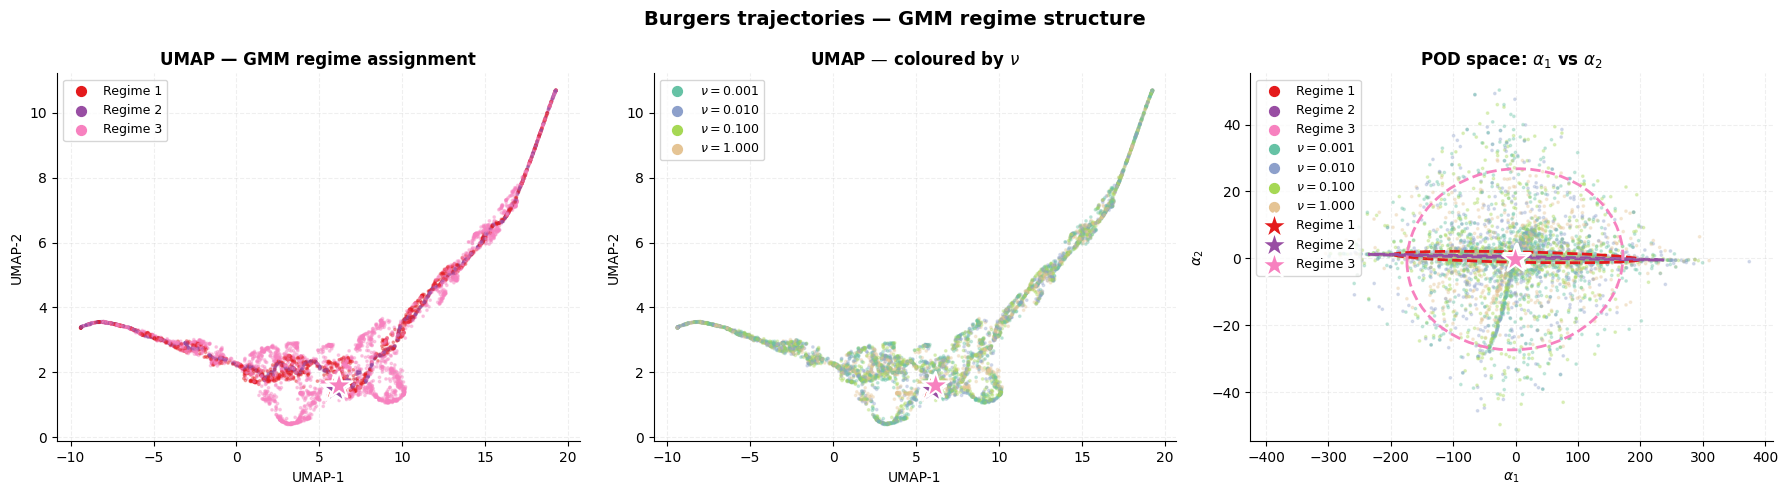

In [ ]:
nu_unique  = np.unique(kappa_viz)
nu_palette = plt.cm.Set2(np.linspace(0, 0.8, len(nu_unique)))
nu_to_col  = {nu: c for nu, c in zip(nu_unique, nu_palette)}
point_colors = np.array([nu_to_col[float(nu)] for nu in kappa_viz])

star_kw = dict(s=400, marker="*", zorder=10, edgecolors="white", linewidths=1.5)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 0: UMAP by regime
axes[0].scatter(embedding[:, 0], embedding[:, 1],
                c=regime_colors[hard_labels], s=3, alpha=0.35, rasterized=True)
axes[0].scatter(mu_umap[:, 0], mu_umap[:, 1], c=regime_colors, **star_kw)
axes[0].set_title("UMAP — GMM regime assignment", fontweight="bold")
handles = [plt.scatter([], [], color=regime_colors[m], s=50, label=f"Regime {m+1}")
           for m in range(cfg.M)]
axes[0].legend(handles=handles, fontsize=9)

# Panel 1: UMAP by nu
axes[1].scatter(embedding[:, 0], embedding[:, 1],
                c=point_colors, s=3, alpha=0.3, rasterized=True)
axes[1].scatter(mu_umap[:, 0], mu_umap[:, 1], c=regime_colors, **star_kw)
axes[1].set_title(r"UMAP — coloured by $\nu$", fontweight="bold")
handles = [plt.scatter([], [], color=nu_to_col[nu], s=50,
                       label=rf"$\nu = {nu:.3f}$") for nu in nu_unique]
axes[1].legend(handles=handles, fontsize=9)

# Panel 2: POD space alpha_1 vs alpha_2
axes[2].scatter(alpha_viz[:, 0], alpha_viz[:, 1],
                c=point_colors, s=3, alpha=0.3, rasterized=True)
for m in range(cfg.M):
    cov2d  = trainer.Sigma[m, :2, :2].cpu().numpy()
    mean2d = mu_np[m, :2]
    draw_cov_ellipse(axes[2], mean2d, cov2d, color=regime_colors[m], linestyle="--")
    axes[2].scatter(*mean2d, color=regime_colors[m], **star_kw, label=f"Regime {m+1}")
axes[2].set_title(r"POD space: $\alpha_1$ vs $\alpha_2$", fontweight="bold")
axes[2].set_xlabel(r"$\alpha_1$"); axes[2].set_ylabel(r"$\alpha_2$")
axes[2].legend(fontsize=9)

for ax in axes[:2]:
    ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
for ax in axes:
    ax.grid(True, ls="--", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Burgers trajectories — GMM regime structure", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

- **t-SNE**:

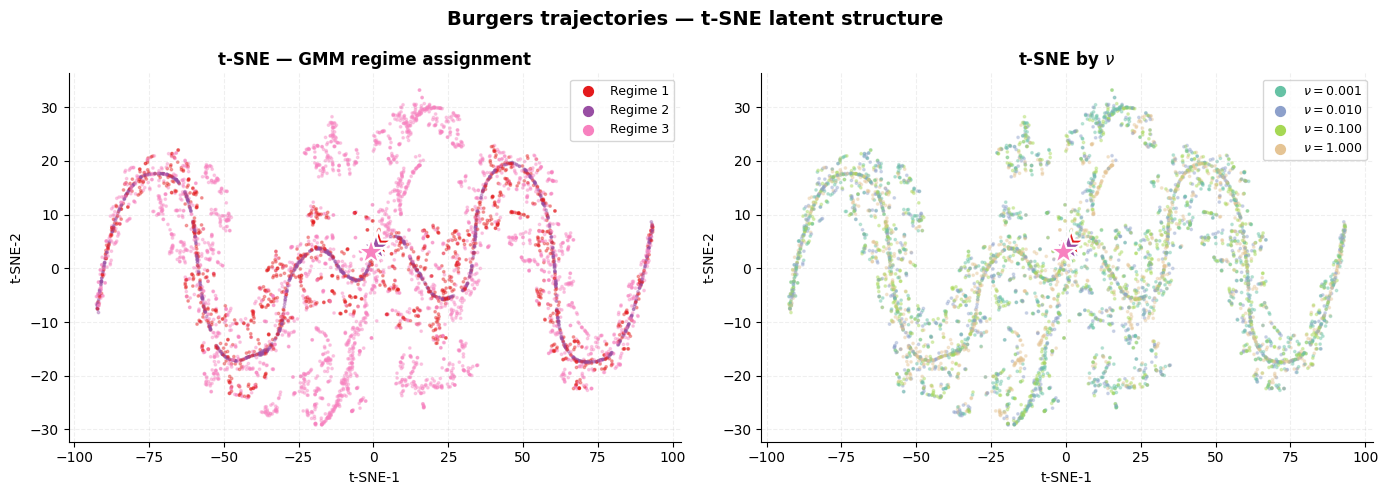

In [ ]:
N_tsne   = 5000
idx_tsne = np.random.choice(len(alpha_viz), N_tsne, replace=False)

alpha_tsne     = alpha_viz[idx_tsne]
kappa_tsne     = kappa_viz[idx_tsne]
hard_tsne      = trainer.gamma[idx][idx_tsne].argmax(dim=1).cpu().numpy()
point_col_tsne = np.array([nu_to_col[float(nu)] for nu in kappa_tsne])

alpha_with_mu = np.vstack([alpha_tsne, mu_np])
emb_all       = TSNE(n_components=2, perplexity=50, random_state=42, n_jobs=-1).fit_transform(alpha_with_mu)
tsne_emb      = emb_all[:-cfg.M]
mu_tsne       = emb_all[-cfg.M:]

star_kw = dict(s=400, marker="*", zorder=10, edgecolors="white", linewidths=1.5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(tsne_emb[:, 0], tsne_emb[:, 1],
                c=regime_colors[hard_tsne], s=3, alpha=0.35, rasterized=True)
axes[0].scatter(mu_tsne[:, 0], mu_tsne[:, 1], c=regime_colors, **star_kw)
axes[0].set_title("t-SNE — GMM regime assignment", fontweight="bold")
handles = [plt.scatter([], [], color=regime_colors[m], s=50, label=f"Regime {m+1}")
           for m in range(cfg.M)]
axes[0].legend(handles=handles, fontsize=9)

axes[1].scatter(tsne_emb[:, 0], tsne_emb[:, 1],
                c=point_col_tsne, s=3, alpha=0.35, rasterized=True)
axes[1].scatter(mu_tsne[:, 0], mu_tsne[:, 1], c=regime_colors, **star_kw)
axes[1].set_title(r"t-SNE by $\nu$", fontweight="bold")
handles = [plt.scatter([], [], color=nu_to_col[nu], s=50,
                       label=rf"$\nu = {nu:.3f}$") for nu in nu_unique]
axes[1].legend(handles=handles, fontsize=9)

for ax in axes:
    ax.set_xlabel("t-SNE-1"); ax.set_ylabel("t-SNE-2")
    ax.grid(True, ls="--", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Burgers trajectories — t-SNE latent structure", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

#### **Fourier Neural POD**

In [ ]:
cfg = TEMPOConfig(
    M=3,
    basis_config=FourierNeuralPODConfig(max_modes=1, n_epochs_mode=5, n_epochs_mean=5),
    basis_factory=fourier_pod_factory,
    P_global = 3
)
trainer_f = TEMPOTrainer(cfg)
trainer_f._initialize(s, x, t=None, kappa=kappa)

POD | N=8000, Ny=25856 | max_modes=3, tol=1.0
  P=3 modes (100.00% variance threshold, needed 8000)
  mode  1: sigma=9.6133e+01  cumvar=91.05%  res_mse=3.5136e-02
  mode  2: sigma=1.0108e+01  cumvar=92.06%  res_mse=3.1184e-02
  mode  3: sigma=9.8191e+00  cumvar=93.01%  res_mse=2.7455e-02
  done: final res_mse=2.7455e-02
Fourier NeuralPOD | N=8000, Ny=25856 | max_modes=1


mean:   0%|          | 0/5 [00:00<?, ?it/s]

mode 1:   0%|          | 0/5 [00:00<?, ?it/s]

  mode 1: weighted_res=2.3792e-02
  done: 1 modes

Fourier NeuralPOD | N=8000, Ny=25856 | max_modes=1


mean:   0%|          | 0/5 [00:00<?, ?it/s]

mode 1:   0%|          | 0/5 [00:00<?, ?it/s]

  mode 1: weighted_res=5.6318e-02
  done: 1 modes

Fourier NeuralPOD | N=8000, Ny=25856 | max_modes=1


mean:   0%|          | 0/5 [00:00<?, ?it/s]

mode 1:   0%|          | 0/5 [00:00<?, ?it/s]

  mode 1: weighted_res=6.0227e-03
  done: 1 modes

  calibrated sigma2 = 1.7638e-02


In [ ]:
N_viz = 5632
idx = np.random.choice(len(s), N_viz, replace=False)

kappa_viz   = kappa[idx, 0].cpu().numpy()
alpha_viz   = trainer_f.alpha[idx].cpu().numpy()
hard_labels = trainer_f.gamma[idx].argmax(dim=1).cpu().numpy()

reducer      = UMAP(n_neighbors=30, min_dist=0.0, random_state=39)
embedding    = reducer.fit_transform(alpha_viz)
mu_np        = trainer_f.mu.cpu().numpy()
mu_umap      = reducer.transform(mu_np)
regime_colors = plt.cm.Set1(np.linspace(0, 0.8, cfg.M))

/Users/rknza/research/m1p/project/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


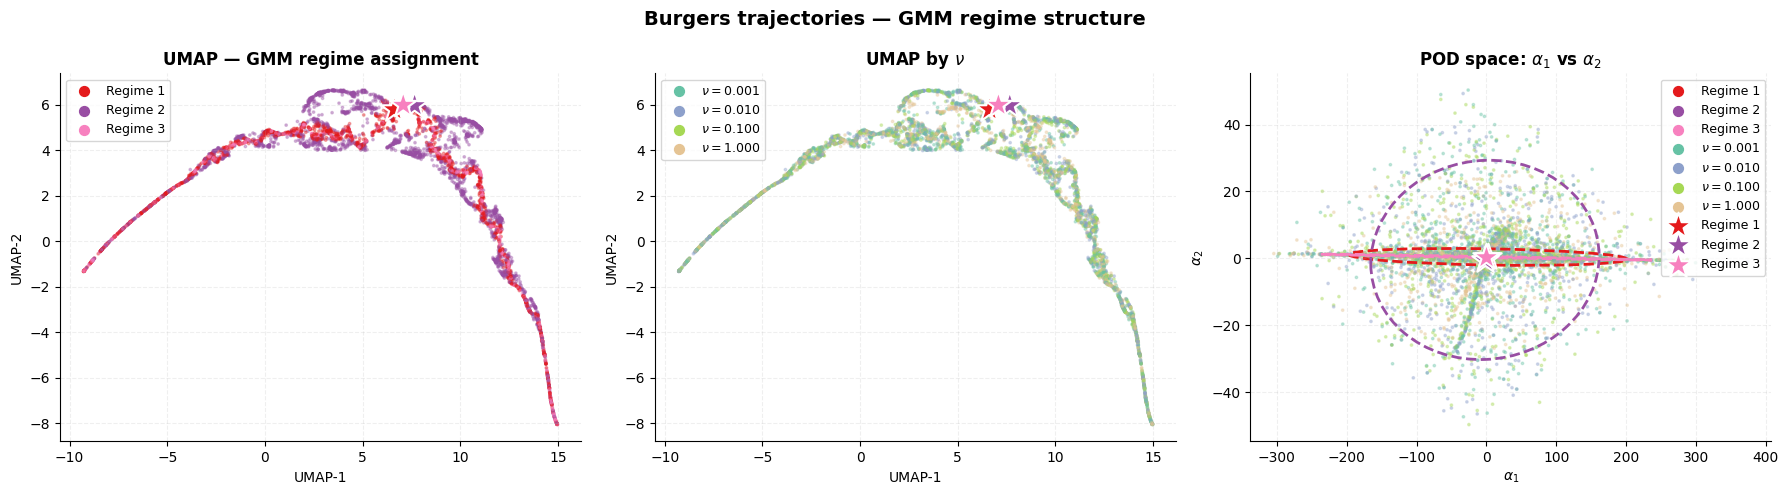

In [ ]:
nu_unique    = np.unique(kappa_viz)
nu_palette   = plt.cm.Set2(np.linspace(0, 0.8, len(nu_unique)))
nu_to_col    = {nu: c for nu, c in zip(nu_unique, nu_palette)}
point_colors = np.array([nu_to_col[float(nu)] for nu in kappa_viz])

star_kw = dict(s=400, marker="*", zorder=10, edgecolors="white", linewidths=1.5)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 0: UMAP by regime
axes[0].scatter(embedding[:, 0], embedding[:, 1],
                c=regime_colors[hard_labels], s=3, alpha=0.35, rasterized=True)
axes[0].scatter(mu_umap[:, 0], mu_umap[:, 1], c=regime_colors, **star_kw)
axes[0].set_title("UMAP — GMM regime assignment", fontweight="bold")
handles = [plt.scatter([], [], color=regime_colors[m], s=50, label=f"Regime {m+1}")
           for m in range(cfg.M)]
axes[0].legend(handles=handles, fontsize=9)

# Panel 1: UMAP by nu
axes[1].scatter(embedding[:, 0], embedding[:, 1],
                c=point_colors, s=3, alpha=0.35, rasterized=True)
axes[1].scatter(mu_umap[:, 0], mu_umap[:, 1], c=regime_colors, **star_kw)
axes[1].set_title(r"UMAP by $\nu$", fontweight="bold")
handles = [plt.scatter([], [], color=nu_to_col[nu], s=50,
                       label=rf"$\nu = {nu:.3f}$") for nu in nu_unique]
axes[1].legend(handles=handles, fontsize=9)

# Panel 2: POD space alpha_1 vs alpha_2
axes[2].scatter(alpha_viz[:, 0], alpha_viz[:, 1],
                c=point_colors, s=3, alpha=0.35, rasterized=True)
for m in range(cfg.M):
    cov2d  = trainer_f.Sigma[m, :2, :2].cpu().numpy()
    mean2d = mu_np[m, :2]
    draw_cov_ellipse(axes[2], mean2d, cov2d, color=regime_colors[m], linestyle="--")
    axes[2].scatter(*mean2d, color=regime_colors[m], **star_kw,
                    label=f"Regime {m+1}")
axes[2].set_title(r"POD space: $\alpha_1$ vs $\alpha_2$", fontweight="bold")
axes[2].set_xlabel(r"$\alpha_1$"); axes[2].set_ylabel(r"$\alpha_2$")
axes[2].legend(fontsize=9)

for ax in axes[:2]:
    ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
for ax in axes:
    ax.grid(True, ls="--", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Burgers trajectories — GMM regime structure",
             fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()